In [1]:
# Core
import pandas as pd
import numpy as np

In [2]:
# Text Processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
# Visualization
!pip install wordcloud
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [4]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\spktd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\spktd\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
train_df = pd.read_csv(r"D:\Herald\AI and ML\Coursework\Task3\train_movie_review.csv")
val_df = pd.read_csv(r"D:\Herald\AI and ML\Coursework\Task3\val_movie_review.csv")
test_df = pd.read_csv(r"D:\Herald\AI and ML\Coursework\Task3\test_movie_review.csv")
print(train_df.head())
print(train_df.info())

   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0
3        6703  A lot people get hung up on this films tag as ...          1
4       28168  I was a fan of Buffy and hoped it would come t...          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  35000 non-null  int64 
 1   review      35000 non-null  object
 2   sentiment   35000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 820.4+ KB
None


In [6]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain sentiment distribution:")
print(train_df['sentiment'].value_counts())

print("\nValidation sentiment distribution:")
print(val_df['sentiment'].value_counts())

print("\nTest sentiment distribution:")
print(test_df['sentiment'].value_counts())

Train shape: (35000, 3)
Validation shape: (5000, 3)
Test shape: (10000, 3)

Train sentiment distribution:
sentiment
0    17584
1    17416
Name: count, dtype: int64

Validation sentiment distribution:
sentiment
1    2545
0    2455
Name: count, dtype: int64

Test sentiment distribution:
sentiment
1    5039
0    4961
Name: count, dtype: int64


In [7]:
for df in [train_df, val_df, test_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
print("Train missing values:")
print(train_df.isnull().sum())

print("\nValidation missing values:")
print(val_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

Train missing values:
review       0
sentiment    0
dtype: int64

Validation missing values:
review       0
sentiment    0
dtype: int64

Test missing values:
review       0
sentiment    0
dtype: int64


In [9]:
train_df = train_df.dropna(subset=['review', 'sentiment'])
val_df = val_df.dropna(subset=['review', 'sentiment'])
test_df = test_df.dropna(subset=['review', 'sentiment'])

In [10]:
train_df['sentiment'] = train_df['sentiment'].astype(int)
val_df['sentiment'] = val_df['sentiment'].astype(int)
test_df['sentiment'] = test_df['sentiment'].astype(int)

In [11]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\spktd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\spktd\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [13]:
train_df['cleaned_review'] = train_df['review'].apply(clean_text)
val_df['cleaned_review'] = val_df['review'].apply(clean_text)
test_df['cleaned_review'] = test_df['review'].apply(clean_text)

train_df[['review', 'cleaned_review', 'sentiment']].head()

,review,cleaned_review,sentiment
0,"Having avoided seeing the movie in the cinema,...",avoided seeing movie cinema buying dvd wife xm...,0
1,With this movie I was really hoping that the i...,movie really hoping idea make hashed together ...,0
2,Raymond Burr stars as an attorney caught up in...,raymond burr star attorney caught murder best ...,0
3,A lot people get hung up on this films tag as ...,lot people get hung film tag childrens film ce...,1
4,I was a fan of Buffy and hoped it would come t...,fan buffy hoped would come proper end angel go...,0


In [14]:
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['cleaned_review'])

In [15]:
X_train_seq = tokenizer.texts_to_sequences(train_df['cleaned_review'])
X_val_seq = tokenizer.texts_to_sequences(val_df['cleaned_review'])
X_test_seq = tokenizer.texts_to_sequences(test_df['cleaned_review'])

In [16]:
print(train_df['cleaned_review'].iloc[0])
print(X_train_seq[0][:20])

avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another characterisation dance number heavily choreographed according extra dvd thrown away half body ever screen dance chorus north european appear small greek island set set number would disgraced cliff richards musical sixtiesmeryl see im actingstreep cant even make usual mugging effective overthetop musical grand piece winner take meryl met note director shot stillness camera gradually showing distance growing streep brosnan singing awful karaoke amateur night camera cannot stop moving like bad mtv one never settle enjoy music enthusiasm character even worse botched piece excre become highest grossing film uk best selling dvd boot blair campbell new labour really reduced uk zombie critical faculty anyone
[3957, 212, 2, 330, 2455, 171, 219, 1, 34, 398, 1

In [17]:
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    "one","get","got","go","make","really","still","even",
    "also","would","could","film","movie","movies"
])

In [18]:
text = " ".join(train_df['cleaned_review'])

In [20]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=100,
    colormap='plasma',   
    contour_color='black',
    contour_width=1
).generate(text)

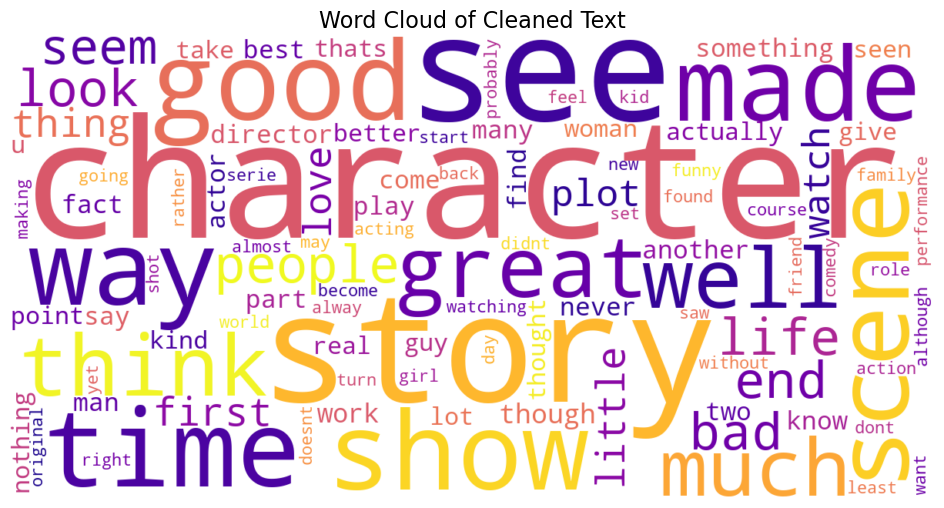

In [21]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Text", fontsize=16)
plt.show()

In [22]:
sequence_lengths = [len(seq) for seq in X_train_seq]

max_len = int(np.percentile(sequence_lengths, 95))

print("95th percentile sequence length:", max_len)

95th percentile sequence length: 305


In [23]:
X_train = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [24]:
y_train = train_df['sentiment'].values
y_val = val_df['sentiment'].values
y_test = test_df['sentiment'].values

In [25]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35000, 305)
X_val shape: (5000, 305)
X_test shape: (10000, 305)
y_train shape: (35000,)
y_val shape: (5000,)
y_test shape: (10000,)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [31]:
#Model 1 Simple RNN (Baseline)
vocab_size = 10000
embedding_dim = 128

In [32]:
model_rnn = Sequential()


In [33]:
# Input Layer

model_rnn.add(Input(shape=(max_len,)))

In [34]:
model_rnn.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    mask_zero=True
))

In [35]:
model_rnn.add(SimpleRNN(64))

In [36]:
model_rnn.add(Dropout(0.5))

In [37]:
model_rnn.add(Dense(1, activation='sigmoid'))

In [38]:
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [39]:
model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 305, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [41]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.6787 - loss: 0.5795 - val_accuracy: 0.8388 - val_loss: 0.3804
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.8311 - loss: 0.3962 - val_accuracy: 0.8310 - val_loss: 0.4071
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.8674 - loss: 0.3156 - val_accuracy: 0.7434 - val_loss: 0.5455


In [42]:
rnn_loss, rnn_accuracy = model_rnn.evaluate(X_test, y_test)

print("Simple RNN Test Accuracy:", rnn_accuracy)
print("Simple RNN Test Loss:", rnn_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8335 - loss: 0.3945
Simple RNN Test Accuracy: 0.8335000276565552
Simple RNN Test Loss: 0.39446893334388733


In [43]:
rnn_pred_prob = model_rnn.predict(X_test)
rnn_pred = (rnn_pred_prob > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


In [44]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, rnn_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84      4961
           1       0.85      0.82      0.83      5039

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



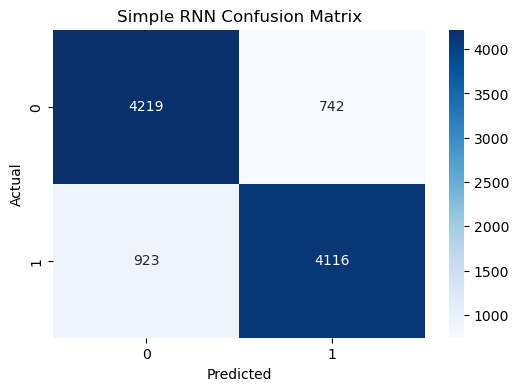

In [45]:
cm_rnn = confusion_matrix(y_test, rnn_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues')
plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

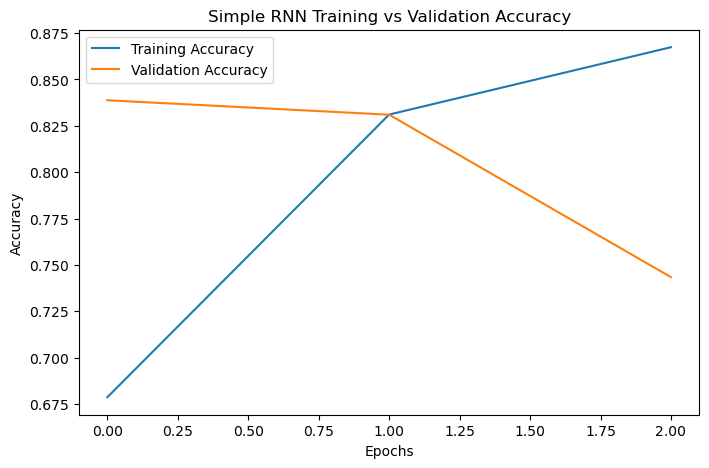

In [46]:
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title("Simple RNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

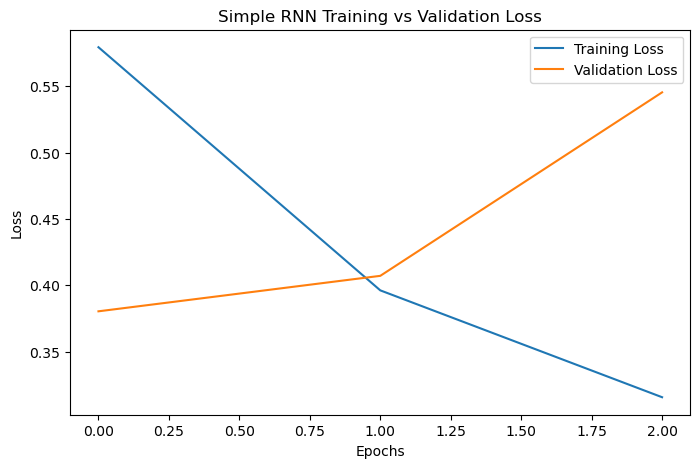

In [47]:
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("Simple RNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [48]:
#Model 2 LSTM
model_lstm = Sequential()


In [49]:
model_lstm.add(Input(shape=(max_len,)))

In [50]:
model_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    mask_zero=True
))

In [51]:
model_lstm.add(LSTM(64))

In [52]:
model_lstm.add(Dropout(0.5))

In [53]:
model_lstm.add(Dense(1, activation='sigmoid'))

In [54]:
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [55]:
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 305, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [57]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_lstm]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 141ms/step - accuracy: 0.8316 - loss: 0.3895 - val_accuracy: 0.8778 - val_loss: 0.3011
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 132ms/step - accuracy: 0.9060 - loss: 0.2498 - val_accuracy: 0.8760 - val_loss: 0.3018
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 69s 126ms/step - accuracy: 0.9276 - loss: 0.1915 - val_accuracy: 0.8790 - val_loss: 0.3343


In [58]:
lstm_loss, lstm_accuracy = model_lstm.evaluate(X_test, y_test)

print("LSTM Test Accuracy:", lstm_accuracy)
print("LSTM Test Loss:", lstm_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8820 - loss: 0.2940
LSTM Test Accuracy: 0.8820000290870667
LSTM Test Loss: 0.29402652382850647


In [59]:
y_pred_lstm = model_lstm.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


In [61]:
y_pred_lstm_classes = (y_pred_lstm > 0.5).astype("int32")

In [62]:
print(classification_report(y_test, y_pred_lstm_classes))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      4961
           1       0.89      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [63]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm_classes)

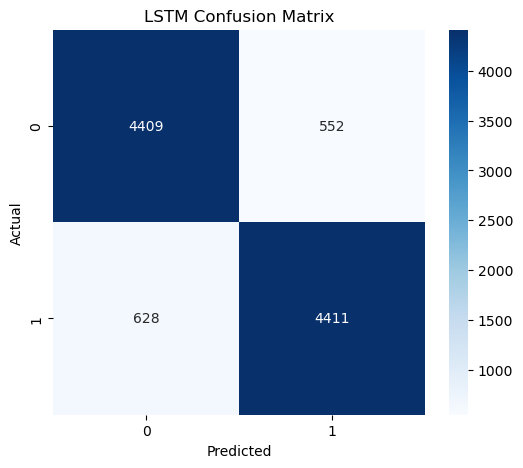

In [64]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

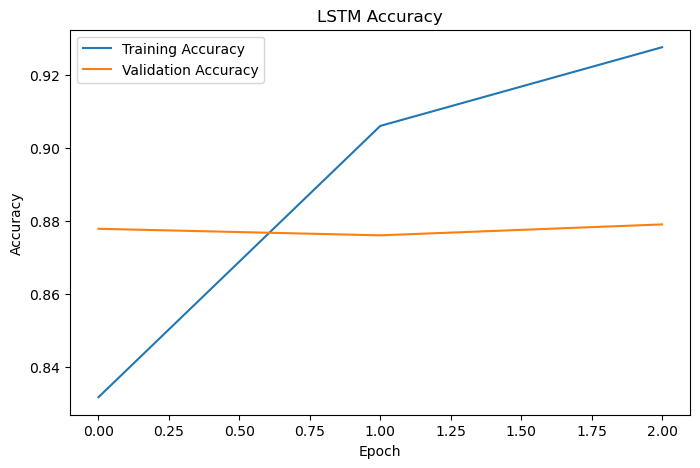

In [65]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

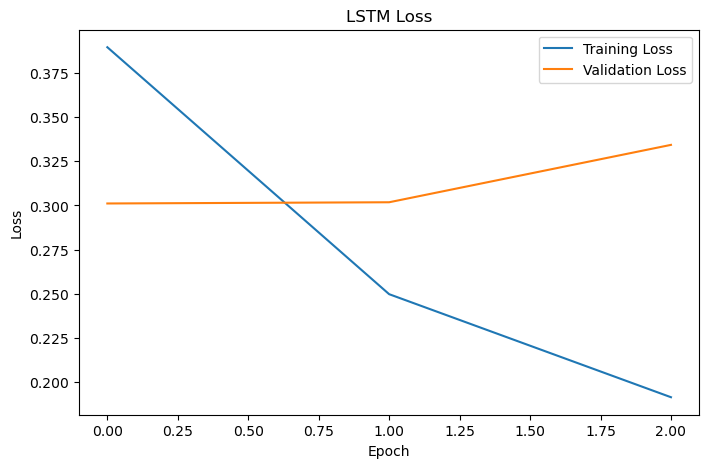

In [66]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
#Model 3 Word2Vec

In [67]:
from gensim.models import Word2Vec
import numpy as np

In [69]:
sentences = train_df['cleaned_review'].apply(lambda x: x.split()).tolist()

In [70]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [71]:
embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i < vocab_size and word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [73]:
model_w2v = Sequential()

In [74]:
model_w2v.add(Input(shape=(max_len,)))

In [75]:
model_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False,
    mask_zero=True
))

In [76]:
model_w2v.add(LSTM(64))

In [77]:
model_w2v.add(Dropout(0.5))

In [78]:
model_w2v.add(Dense(1, activation='sigmoid'))

In [79]:
model_w2v.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [80]:
model_w2v.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 305, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,042,305 (3.98 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [81]:
early_stop_w2v = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [82]:
history_w2v = model_w2v.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_w2v]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 65s 116ms/step - accuracy: 0.8223 - loss: 0.4027 - val_accuracy: 0.8618 - val_loss: 0.3292
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 60s 109ms/step - accuracy: 0.8631 - loss: 0.3287 - val_accuracy: 0.8710 - val_loss: 0.3029
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 60s 109ms/step - accuracy: 0.8769 - loss: 0.3007 - val_accuracy: 0.8748 - val_loss: 0.2890
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 60s 109ms/step - accuracy: 0.8853 - loss: 0.2823 - val_accuracy: 0.8740 - val_loss: 0.2920
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 60s 109ms/step - accuracy: 0.8914 - loss: 0.2723 - val_accuracy: 0.8846 - val_loss: 0.2751
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 61s 112ms/step - accuracy: 0.8970 - loss: 0.2619 - val_accuracy: 0.8846 - val_loss: 0.2801
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 61s 112ms/step - accuracy: 0.9011 - loss: 0.2508 - val_accuracy: 0.8880 - val_loss: 0.2694
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 60s 109ms/step - accuracy: 0.9067 - loss: 0

In [83]:
w2v_loss, w2v_accuracy = model_w2v.evaluate(X_test, y_test)

print("Word2Vec + LSTM Accuracy:", w2v_accuracy)
print("Word2Vec + LSTM Loss:", w2v_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8849 - loss: 0.2745
Word2Vec + LSTM Accuracy: 0.8848999738693237
Word2Vec + LSTM Loss: 0.2744605839252472


In [84]:
y_pred_w2v = model_w2v.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


In [85]:
y_pred_w2v_classes = (y_pred_w2v > 0.5).astype("int32")

In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_w2v_classes))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88      4961
           1       0.86      0.92      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



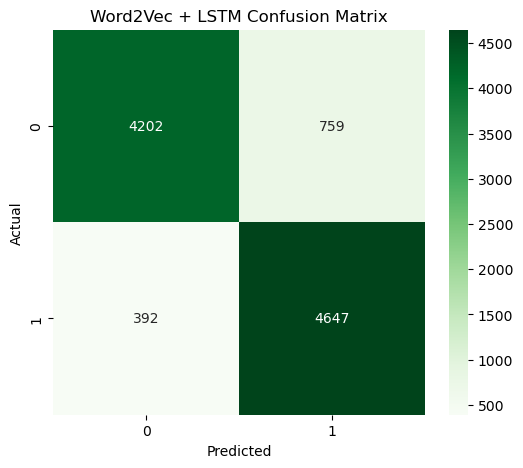

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_w2v = confusion_matrix(y_test, y_pred_w2v_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_w2v,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Word2Vec + LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

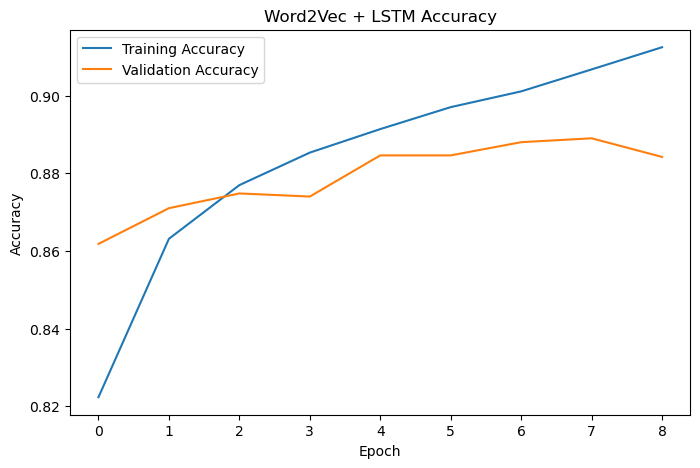

In [88]:
plt.figure(figsize=(8,5))

plt.plot(history_w2v.history['accuracy'], label='Training Accuracy')
plt.plot(history_w2v.history['val_accuracy'], label='Validation Accuracy')

plt.title("Word2Vec + LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

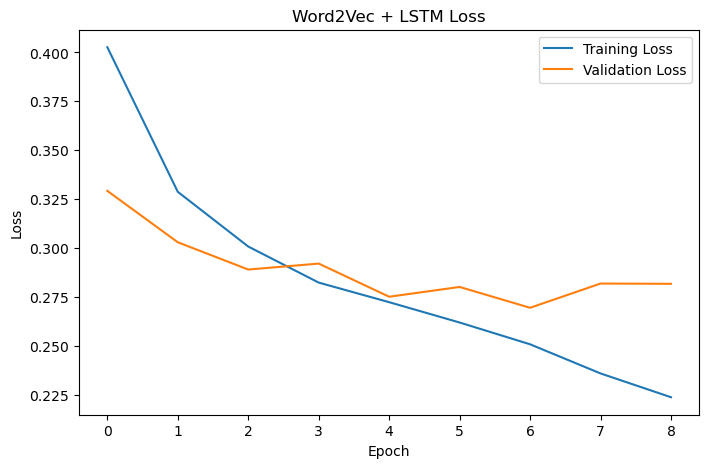

In [89]:
plt.figure(figsize=(8,5))

plt.plot(history_w2v.history['loss'], label='Training Loss')
plt.plot(history_w2v.history['val_loss'], label='Validation Loss')

plt.title("Word2Vec + LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

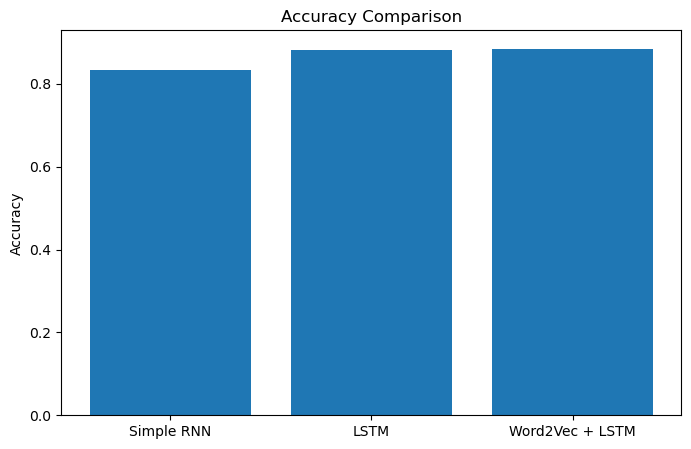

In [90]:
models = ['Simple RNN', 'LSTM', 'Word2Vec + LSTM']

accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    w2v_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [92]:
model_w2v.save("sentiment_model.keras")

In [93]:
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [95]:
import pickle

model_w2v_lstm.save(r"D:\Herald\AI and ML\Coursework\Task3\sentiment_model.keras")

with open(r"D:\Herald\AI and ML\Coursework\Task3\tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open(r"D:\Herald\AI and ML\Coursework\Task3\max_len.pkl", "wb") as f:
    pickle.dump(max_len, f)

print("Model, tokenizer, and max_len saved successfully.")

NameError: name 'model_w2v_lstm' is not defined

In [96]:
import pickle
import os

# Create save directory if it does not exist
save_path = r"D:\Herald\AI and ML\Coursework\Task3"

os.makedirs(save_path, exist_ok=True)

# Save trained model
model_w2v.save(
    os.path.join(save_path, "sentiment_model.keras")
)

# Save tokenizer
with open(
    os.path.join(save_path, "tokenizer.pkl"),
    "wb"
) as f:

    pickle.dump(tokenizer, f)

# Save max sequence length
with open(
    os.path.join(save_path, "max_len.pkl"),
    "wb"
) as f:

    pickle.dump(max_len, f)

print("Model, tokenizer, and max_len saved successfully.")

Model, tokenizer, and max_len saved successfully.
